# ACTIVIDAD 12
# VICTOR CEN

In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt
import logging

import tensorflow as tf
import tensorflow_datasets as tfds

In [7]:
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [9]:
dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

In [11]:
class_names = [
    'Cero', 'Uno', 'Dos', 'Tres', 'Cuatro',
    'Cinco', 'Seis', 'Siete', 'Ocho', 'Nueve'
]

In [13]:
num_train_examples = metadata.splits['train'].num_examples
num_test_examples = metadata.splits['test'].num_examples

print("Ejemplos de entrenamiento:", num_train_examples)
print("Ejemplos de prueba:", num_test_examples)

Ejemplos de entrenamiento: 60000
Ejemplos de prueba: 10000


In [15]:
def normalize(images, labels):
    images = tf.cast(images, tf.float32)
    images /= 255
    return images, labels

In [17]:
train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)

I0000 00:00:1773800278.808894  909463 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
W0000 00:00:1773800278.901817  909468 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


Etiqueta real: 4


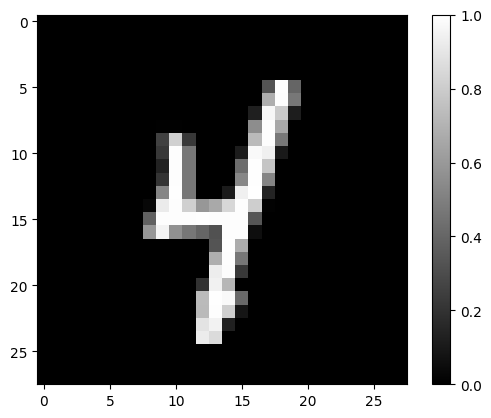

In [19]:
for image, label in train_dataset.take(1):
    print("Etiqueta real:", label.numpy())
    plt.imshow(image[:, :, 0], cmap='gray')
    plt.colorbar()
    plt.show()

In [21]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

/opt/anaconda3/envs/uni-tf311/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
BATCHSIZE = 32

train_dataset = train_dataset.repeat().shuffle(num_train_examples).batch(BATCHSIZE)
test_dataset = test_dataset.batch(BATCHSIZE)

In [27]:
history = model.fit(
    train_dataset,
    epochs=5,
    steps_per_epoch=math.ceil(num_train_examples / BATCHSIZE)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 626us/step - accuracy: 0.9223 - loss: 0.2660
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 624us/step - accuracy: 0.9625 - loss: 0.1219
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 634us/step - accuracy: 0.9725 - loss: 0.0881
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 618us/step - accuracy: 0.9783 - loss: 0.0697
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 670us/step - accuracy: 0.9826 - loss: 0.0559


In [29]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    steps=math.ceil(num_test_examples / BATCHSIZE)
)

print("Resultado en las pruebas:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/step - accuracy: 0.9731 - loss: 0.0939
Resultado en las pruebas: 0.9731000065803528


In [32]:
for test_images, test_labels in test_dataset.take(1):
    test_images = test_images.numpy()
    test_labels = test_labels.numpy()
    predictions = model.predict(test_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [34]:
def plot_image(i, predictions_array, true_labels, images):
    predictions_array, true_label, img = predictions_array[i], true_labels[i], images[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[..., 0], cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("Predicción: {}".format(class_names[predicted_label]), color=color)

In [36]:
def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#888888")
    plt.ylim([0, 1])

    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

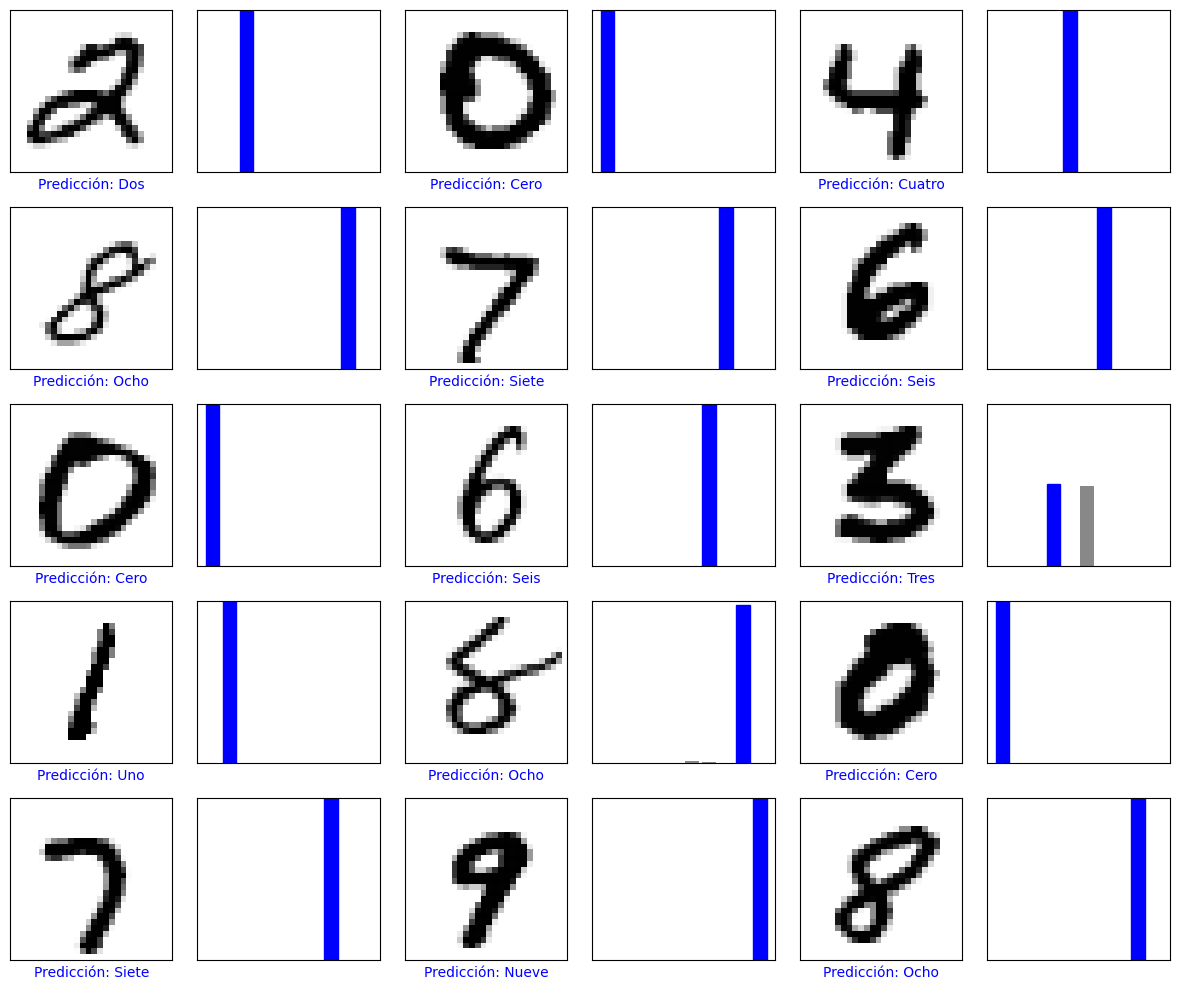

In [38]:
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))

for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions, test_labels, test_images)

    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, predictions, test_labels)

plt.tight_layout()
plt.show()

## PARTE 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from urllib import parse
from http.server import HTTPServer, BaseHTTPRequestHandler

In [2]:
mnist = tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [5]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [7]:
train_images = train_images[..., np.newaxis]
test_images = test_images[..., np.newaxis]

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/opt/anaconda3/envs/uni-tf311/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 540us/step - accuracy: 0.9127 - loss: 0.2980 - val_accuracy: 0.9645 - val_loss: 0.1253
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 506us/step - accuracy: 0.9602 - loss: 0.1294 - val_accuracy: 0.9673 - val_loss: 0.1080
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 507us/step - accuracy: 0.9710 - loss: 0.0931 - val_accuracy: 0.9703 - val_loss: 0.0988
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 503us/step - accuracy: 0.9770 - loss: 0.0728 - val_accuracy: 0.9757 - val_loss: 0.0798
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 505us/step - accuracy: 0.9805 - loss: 0.0593 - val_accuracy: 0.9738 - val_loss: 0.0895


In [15]:
class SimpleHTTPRequestHandler(BaseHTTPRequestHandler):
    def do_POST(self):
        print("Peticion recibida")

        # Obtener longitud del contenido
        content_length = int(self.headers['Content-Length'])

        # Leer datos
        data = self.rfile.read(content_length)
        data = data.decode().replace('pixeles=', '')
        data = parse.unquote(data)

        

        # Dar forma como imagen MNIST
        arr = np.fromstring(data, np.float32, sep=",")
        arr = arr.reshape(28, 28)

        plt.imshow(arr, cmap='gray')
        plt.title("Imagen recibida del canvas")
        plt.colorbar()
        plt.show()

        arr = np.array(arr)
        arr = arr.reshape(1, 28, 28, 1)
           
 

        # Predecir
        prediction_values = model.predict(arr, batch_size=1)
        prediction = str(np.argmax(prediction_values))

        print("Prediccion final:", prediction)

        # Responder al navegador
        self.send_response(200)
        self.send_header("Access-Control-Allow-Origin", "*")
        self.end_headers()
        self.wfile.write(prediction.encode())

Iniciando el servidor...
Peticion recibida


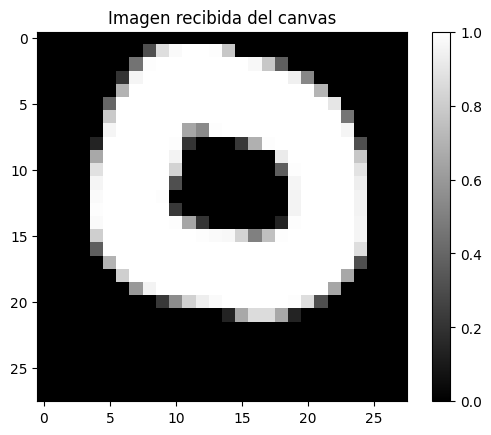

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Prediccion final: 6


127.0.0.1 - - [17/Mar/2026 21:28:56] "POST / HTTP/1.1" 200 -


Peticion recibida


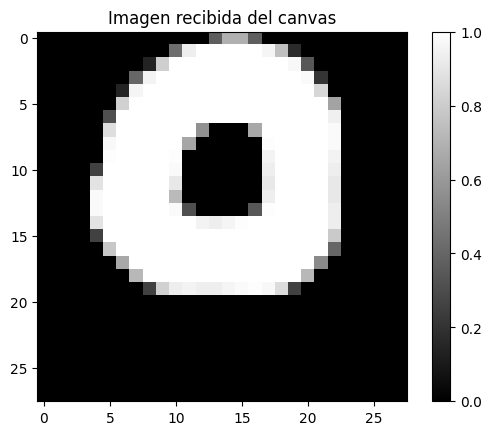

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Prediccion final: 6


127.0.0.1 - - [17/Mar/2026 21:29:06] "POST / HTTP/1.1" 200 -


Peticion recibida


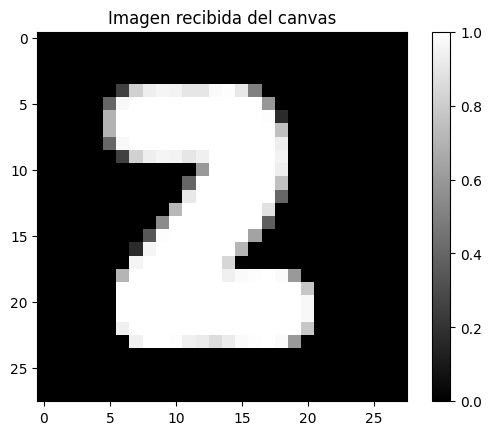

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediccion final: 2


127.0.0.1 - - [17/Mar/2026 21:29:11] "POST / HTTP/1.1" 200 -


Peticion recibida


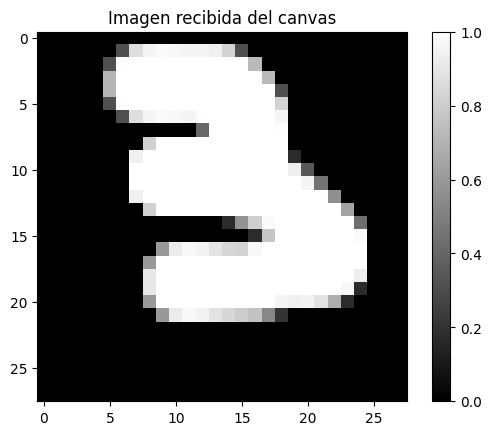

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediccion final: 6


127.0.0.1 - - [17/Mar/2026 21:29:17] "POST / HTTP/1.1" 200 -


Peticion recibida


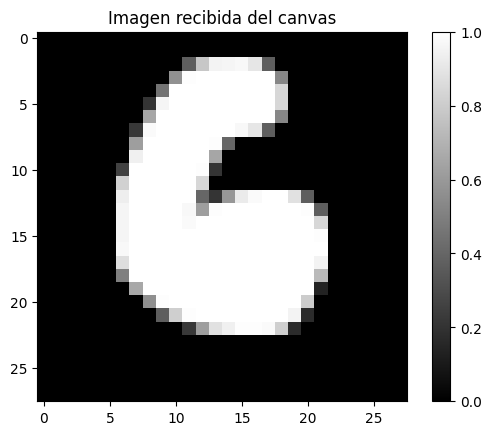

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediccion final: 6


127.0.0.1 - - [17/Mar/2026 21:29:22] "POST / HTTP/1.1" 200 -


Peticion recibida


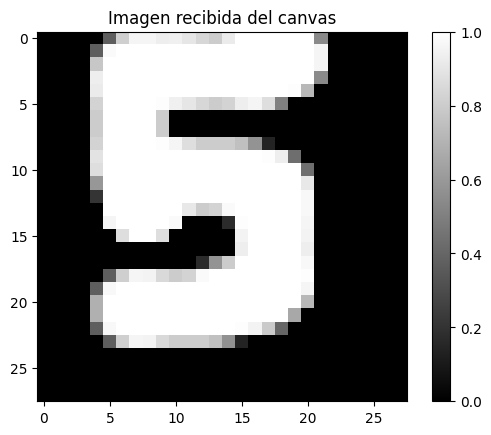

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediccion final: 6


127.0.0.1 - - [17/Mar/2026 21:29:27] "POST / HTTP/1.1" 200 -


Peticion recibida


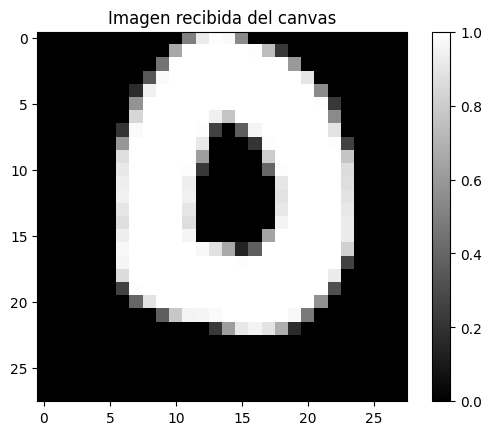

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediccion final: 6


127.0.0.1 - - [17/Mar/2026 21:29:32] "POST / HTTP/1.1" 200 -


Peticion recibida


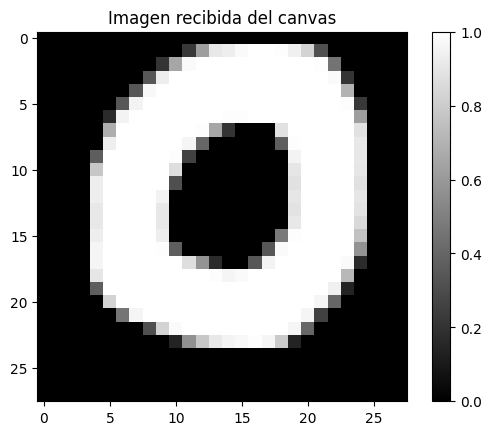

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediccion final: 6


127.0.0.1 - - [17/Mar/2026 21:29:37] "POST / HTTP/1.1" 200 -


Peticion recibida


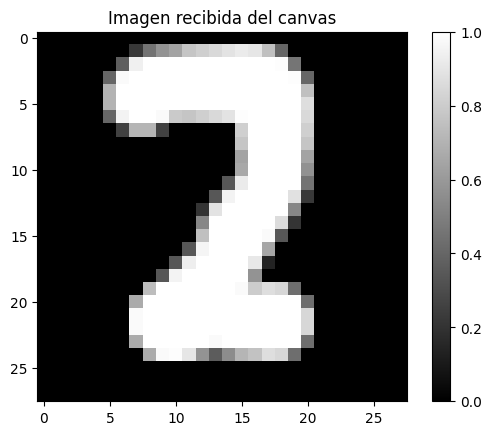

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediccion final: 2


127.0.0.1 - - [17/Mar/2026 21:29:41] "POST / HTTP/1.1" 200 -


Peticion recibida


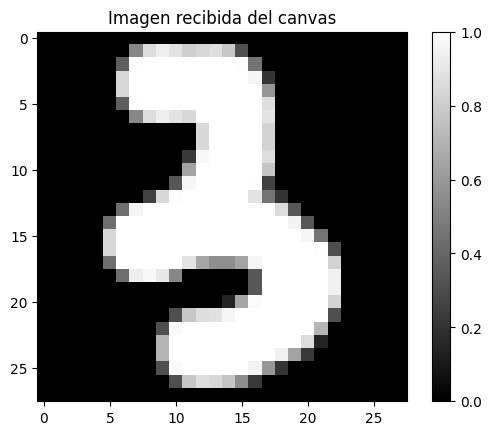

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediccion final: 3


127.0.0.1 - - [17/Mar/2026 21:29:45] "POST / HTTP/1.1" 200 -


Peticion recibida


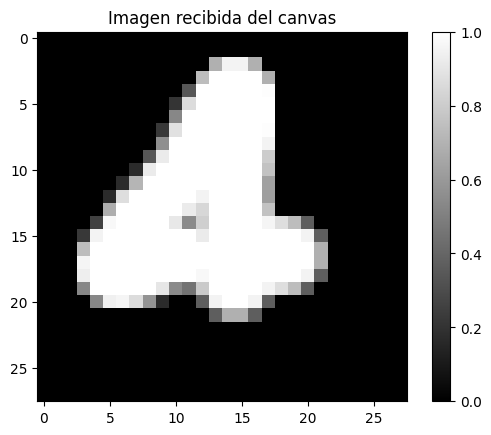

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediccion final: 4


127.0.0.1 - - [17/Mar/2026 21:29:56] "POST / HTTP/1.1" 200 -


Peticion recibida


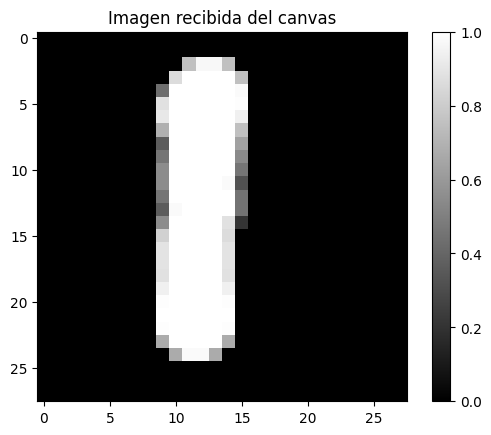

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediccion final: 8


127.0.0.1 - - [17/Mar/2026 21:30:16] "POST / HTTP/1.1" 200 -


Peticion recibida


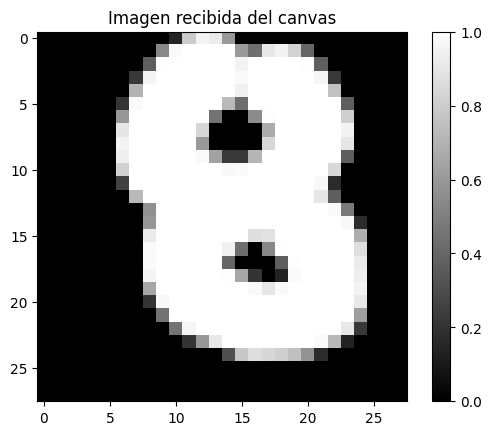

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediccion final: 8


127.0.0.1 - - [17/Mar/2026 21:30:26] "POST / HTTP/1.1" 200 -


Peticion recibida


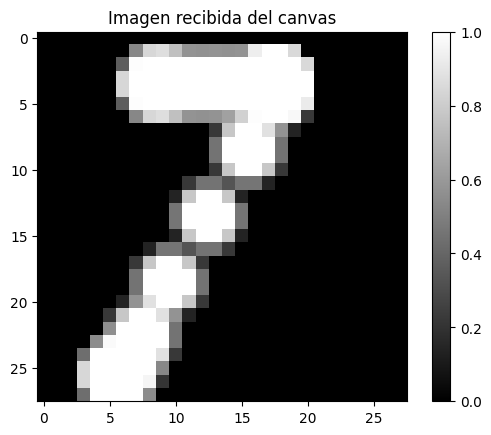

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediccion final: 3


127.0.0.1 - - [17/Mar/2026 21:30:29] "POST / HTTP/1.1" 200 -


Peticion recibida


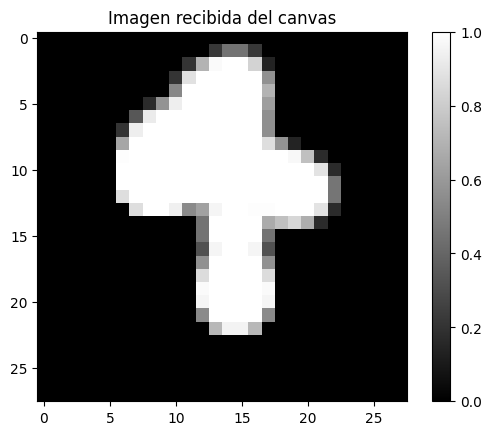

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediccion final: 8


127.0.0.1 - - [17/Mar/2026 21:30:51] "POST / HTTP/1.1" 200 -


In [ ]:
print("Iniciando el servidor...")
server = HTTPServer(('localhost', 8000), SimpleHTTPRequestHandler)
server.serve_forever()